In [1]:
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('../data/friends_features.csv', index_col='user_id')
df.sample(5)

,friend_id,is_friend,common_friends_count,demographics_sex_user,demographics_age_user,demographics_city_user,education_career_education_university_user,education_career_education_faculty_user,demographics_sex_friend,demographics_age_friend,demographics_city_friend,education_career_education_university_friend,education_career_education_faculty_friend
user_id,,,,,,,,,,,,,
286877958,275267938,True,90,мужской,22.0,Москва,Неизвестно,Неизвестно,мужской,22.0,Таганрог,Неизвестно,Неизвестно
359178717,269388306,True,25,мужской,22.0,Москва,Неизвестно,Неизвестно,мужской,22.0,Москва,Неизвестно,Неизвестно
174135567,176943398,False,0,мужской,23.0,Ōfunato,Неизвестно,Неизвестно,мужской,22.0,Бронницы,Неизвестно,Неизвестно
394100799,254249175,True,19,мужской,20.0,Москва,РТУ МИРЭА,Институт информационных технологий,мужской,21.0,Пенза,РТУ МИРЭА,Неизвестно
319349113,154151541,True,3,мужской,22.0,Жуковский,Неизвестно,Неизвестно,мужской,22.0,Химки,Неизвестно,Неизвестно


In [3]:
df['is_friend'].value_counts()

is_friend
True     683
False    342
Name: count, dtype: int64

In [4]:
X = df.drop(columns=['friend_id', 'is_friend'])
y = df['is_friend']

cat_features = ['demographics_sex_user',
                'demographics_city_user',
                'education_career_education_university_user',
                'education_career_education_faculty_user',
                'demographics_sex_friend',
                'demographics_city_friend',
                'education_career_education_university_friend',
                'education_career_education_faculty_friend']

X_train, X_test, y_train, y_test= train_test_split(X, y, train_size=0.8, random_state=42, shuffle=True)

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(820, 11)
(820,)
(205, 11)
(205,)


In [5]:
model = CatBoostClassifier(iterations=500,
                           learning_rate=0.01,
                           depth=8,
                           loss_function='Logloss',
                           eval_metric='Accuracy',
                           cat_features=cat_features,
                           random_seed=42,
                           task_type='GPU',
                           devices='0',
                           verbose=50)

In [6]:
model.fit(X_train, y_train, eval_set=(X_test, y_test))

0:	learn: 0.9256098	test: 0.9170732	best: 0.9170732 (0)	total: 44.9ms	remaining: 22.4s
50:	learn: 0.9243902	test: 0.9121951	best: 0.9170732 (0)	total: 2.36s	remaining: 20.7s
100:	learn: 0.9243902	test: 0.9121951	best: 0.9170732 (0)	total: 4.91s	remaining: 19.4s
150:	learn: 0.9268293	test: 0.9121951	best: 0.9170732 (0)	total: 8.32s	remaining: 19.2s
200:	learn: 0.9304878	test: 0.9170732	best: 0.9170732 (0)	total: 11.9s	remaining: 17.8s
250:	learn: 0.9341463	test: 0.9170732	best: 0.9170732 (0)	total: 15.6s	remaining: 15.4s
300:	learn: 0.9390244	test: 0.9170732	best: 0.9170732 (0)	total: 19s	remaining: 12.6s
350:	learn: 0.9426829	test: 0.9219512	best: 0.9219512 (320)	total: 23s	remaining: 9.75s
400:	learn: 0.9439024	test: 0.9268293	best: 0.9268293 (366)	total: 26.5s	remaining: 6.55s
450:	learn: 0.9451220	test: 0.9268293	best: 0.9268293 (366)	total: 30s	remaining: 3.26s
499:	learn: 0.9475610	test: 0.9317073	best: 0.9317073 (497)	total: 33.3s	remaining: 0us
bestTest = 0.9317073171
bestIterat

In [7]:
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.9317073170731708


In [8]:
new_data = pd.DataFrame([{
    "common_friends_count": 1,
    "demographics_sex_user": "мужской",
    "demographics_age_user": 22.0,
    "demographics_city_user": "Москва",
    "education_career_education_university_user": "РТУ МИРЭА",
    "education_career_education_faculty_user": "Неизвестно",
    "demographics_sex_friend": "женский",  
    "demographics_age_friend": 25.0,       
    "demographics_city_friend": "Москва",  
    "education_career_education_university_friend": "МГУ",  
    "education_career_education_faculty_friend": "Неизвестно"   
}])

new_data = new_data[X_train.columns]

pred = model.predict(new_data)
print("Predict:", pred)

prob = model.predict_proba(new_data)
print("Friend chance:", prob[0][1])

Predict: [False]
Friend chance: 0.011266064144207636


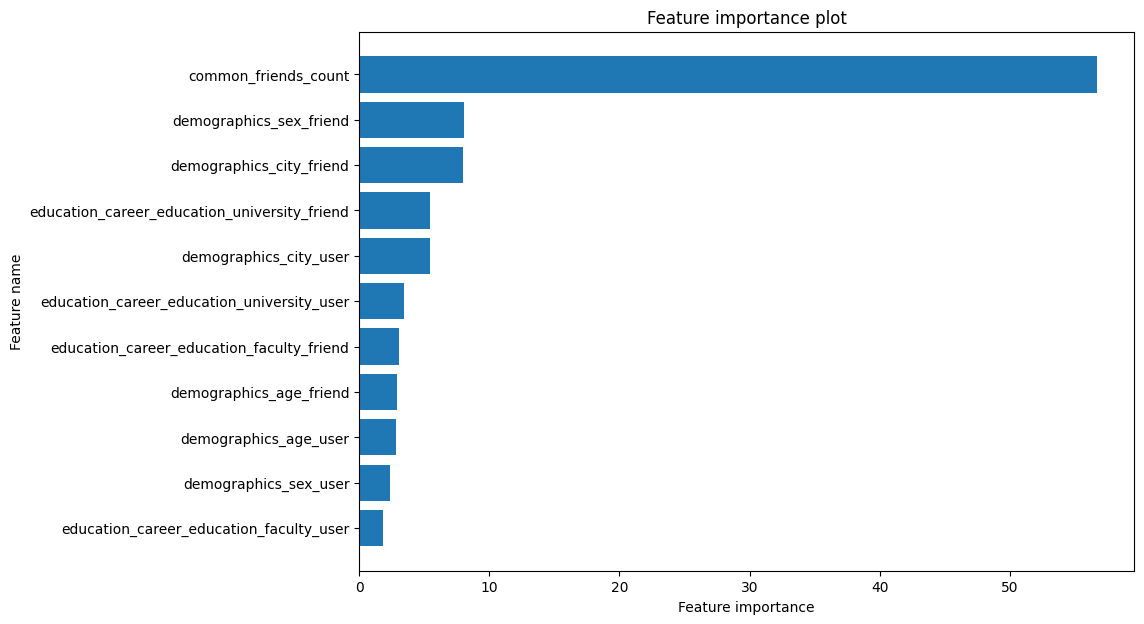

In [9]:
import matplotlib.pyplot as plt


feature_importance = model.get_feature_importance()
feature_names = X_train.columns

importance_df = pd.DataFrame({'feature_name': feature_names,
                              'feature_importance': feature_importance}).sort_values(by='feature_importance', ascending=True)

plt.figure(figsize=(10,7))
plt.barh(importance_df['feature_name'], importance_df['feature_importance'])
plt.ylabel('Feature name')
plt.xlabel('Feature importance')
plt.title('Feature importance plot')
# plt.xticks(rotation=45, ha='right')
plt.show()